In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import librosa as lb
import soundfile as sf
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report
from tensorflow.keras import layers, models, activations
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from smart_stethoscope.interface import main
X_train, X_test, y_train, y_test, train_cycle_filenames, test_cycle_filenames = main.preprocessing()


✅ Processed audio files already exist, skipping extraction

Load data from cached CSV...


/Users/miameyer/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [4]:
train_cycle_filenames

array(['148_1b1_Al_sc_Meditron_0', '148_1b1_Al_sc_Meditron_1',
       '148_1b1_Al_sc_Meditron_2', ..., '116_1b2_Pl_sc_Meditron_1',
       '116_1b2_Pl_sc_Meditron_2', '116_1b2_Pl_sc_Meditron_3'],
      shape=(5806,), dtype=object)

In [13]:
def get_audio_data(cycle_filenames):
  folder = Path('../preprocessed_data/padded_audio_breathing_cycles')
  audios = []
  for filename in cycle_filenames:
    filename = filename + ".wav"
    full_file_name = folder / filename
    audio, sr = lb.load(full_file_name, sr=None)
    audios.append(audio)
  audio_array = np.stack(audios).astype(np.float32)
  return audio_array

In [14]:
audio_train_array = get_audio_data(train_cycle_filenames)
audio_test_array = get_audio_data(test_cycle_filenames)

In [59]:
def get_mels(audio_array):
    mels =[]
    for audio in audio_array:
        mel_spec = lb.feature.melspectrogram(
            y=audio,
            sr=22050,
            n_mels=128
        )
        # Convert to decibel scale for better modelling / visualisation
        mel_spec_db = lb.power_to_db(mel_spec, ref=np.max)
        mels.append(mel_spec_db)
        features = np.stack(mels)
        features = features[..., np.newaxis]
    return np.stack(features)

In [60]:
mels_train = get_mels(audio_train_array)
mels_test = get_mels(audio_test_array)

In [61]:
X_train_img = mels_train
X_test_img = mels_test

### Encode Calss Labels

In [17]:
# Check shape of data
print("y_train shape before encoding:", y_train.shape)
print("y_test shape before encoding:", y_test.shape)

# Check class labels
print("Unique train labels:", sorted(y_train.unique()))
print("Unique test labels:", sorted(y_test.unique()))

# Calculate number of classes
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

y_train shape before encoding: (5806,)
y_test shape before encoding: (1054,)
Unique train labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Unique test labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Number of classes: 6


In [20]:
# Convert integer labels to one-hot encoded arrays
# Example: class 2 becomes [0, 0, 1, 0, 0, 0]
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Check the new shapes
print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

# Look at one example
print("First raw label:", y_train.iloc[0])
print("First one-hot label:", y_train_cat[0])

y_train_cat shape: (5806, 6)
y_test_cat shape: (1054, 6)
First raw label: 2
First one-hot label: [0. 0. 1. 0. 0. 0.]


### Build CNN

In [62]:
input_shape = X_train_img.shape[1:]
input_shape

(128, 259, 1)

In [39]:
# Convert one-hot back to integer labels
y_train_int = np.argmax(y_train_cat, axis=1)

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weights_dict = dict(enumerate(class_weights))

### Test Model from Notebook

In [97]:
mSpec_input=layers.Input(shape=input_shape,name="mSpecInput")
x=layers.Conv2D(32,5,strides=(2,3),padding='same')(mSpec_input)
x=layers.BatchNormalization()(x)
x=layers.Activation(activations.relu)(x)
x=layers.MaxPooling2D(pool_size=2,padding='valid')(x)

x=layers.Conv2D(64,3,strides=(2,2),padding='same')(x)
x=layers.BatchNormalization()(x)
x=layers.Activation(activations.relu)(x)
x=layers.MaxPooling2D(pool_size=2,padding='valid')(x)

x=layers.Conv2D(96,2,padding='same')(x)
x=layers.BatchNormalization()(x)
x=layers.Activation(activations.relu)(x)
x=layers.MaxPooling2D(pool_size=2,padding='valid')(x)

x=layers.Conv2D(128,2,padding='same')(x)
x=layers.BatchNormalization()(x)
x=layers.Activation(activations.relu)(x)
x=layers.GlobalMaxPooling2D()(x)

x = layers.Dense(32, activations.relu)(x)
x = layers.Dropout(0.3)(x)
mSpec_output = layers.Dense(num_classes, activations.softmax)(x)

mSpec_model=tf.keras.Model(mSpec_input, mSpec_output, name="mSpecModel")

In [98]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001)
mSpec_model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [99]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20, # instead of 3
    restore_best_weights=True
)
my_callbacks = [
    early_stopping,
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                              patience=3, min_lr=0.00001,mode='min')
]

history = mSpec_model.fit(
    X_train_img,
    y_train_cat,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[my_callbacks],
    verbose=1
)

test_loss, test_accuracy = mSpec_model.evaluate(X_test_img, y_test_cat, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Epoch 1/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.3611 - loss: 1.8324 - val_accuracy: 0.1687 - val_loss: 1.5006 - learning_rate: 0.0010
Epoch 2/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.4414 - loss: 1.5285 - val_accuracy: 0.2943 - val_loss: 1.6202 - learning_rate: 0.0010
Epoch 3/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.4875 - loss: 1.4545 - val_accuracy: 0.5886 - val_loss: 1.2736 - learning_rate: 0.0010
Epoch 4/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5758 - loss: 1.2315 - val_accuracy: 0.7943 - val_loss: 0.6224 - learning_rate: 0.0010
Epoch 5/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6135 - loss: 1.0818 - val_accuracy: 0.8752 - val_loss: 0.4718 - learning_rate: 0.0010
Epoch 6/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6014 - loss: 1.1026 - val_accuracy: 0.8451 - val_loss: 0.4647 - learning_rate: 0.0010
Epoch 7/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6675 - l

In [100]:
# Predict and evaluate
y_pred_probs = mSpec_model.predict(X_test_img)

y_pred_cnn = np.argmax(y_pred_probs, axis=1)
y_test_int = np.argmax(y_test_cat, axis=1)

print(classification_report(y_test_int, y_pred_cnn, zero_division=0))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

           0       0.24      0.49      0.33        57
           1       0.97      0.91      0.94       891
           2       0.21      0.26      0.23        43
           3       0.00      0.00      0.00        24
           4       0.53      0.35      0.42        26
           5       0.00      0.00      0.00        13

    accuracy                           0.82      1054
   macro avg       0.32      0.33      0.32      1054
weighted avg       0.85      0.82      0.83      1054



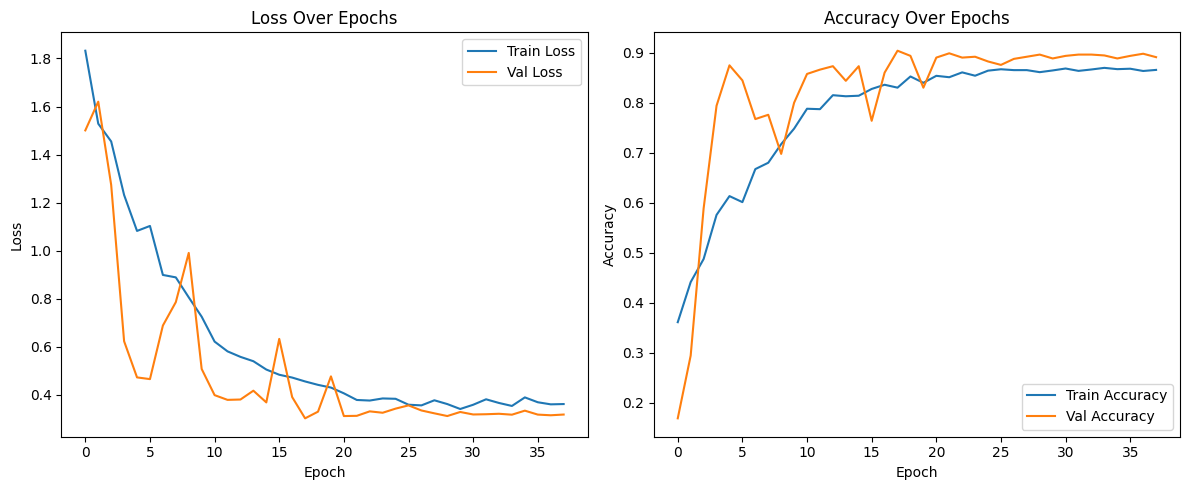

In [101]:
# Plot training vs validation curves

history_dict = history.history

# Loss plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()